<a href="https://colab.research.google.com/github/sascott9655/ADS-504-Mushroom-Classification-Project/blob/main/Final_Project_Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mushroom Classification Project
###Samuel Scott, Julia Gonzalez, Bereket Tarekegn

**Project Goal:** Using machine learning techniques be able to properly determine if a mushrooms is poisonous or edible. This could be applied by reducing risk for cooks who use mushrooms to cook recipes, and collectors/foragers who rely on accurate identification of mushrooms. Based on observable features such as cap shape, gill structure, habitat, etc. to determine whether a mushroom is classified as edible or poisonous. This problem is important to solve as mushrooms if poisonous and consumed by humans can cause serious health effects such as organ failure or even death. Since the visual of mushrooms can be quite similar between poisonous and edible mushrooms, having a distinct classifier to detect mushroom edibility would provide safer decision making for cooks, foragers, and people that consume mushrooms.  

*Note: There is a text file called secondary_data_meta.txt that discusses what the unique values of some of the predictors mean.*

In [1]:
!git clone https://github.com/sascott9655/ADS-504-Mushroom-Classification-Project

Cloning into 'ADS-504-Mushroom-Classification-Project'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 39 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 900.31 KiB | 2.57 MiB/s, done.
Resolving deltas: 100% (20/20), done.


###Imports:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance


#Section 1: Read in the Data

In [3]:
df = pd.read_csv('ADS-504-Mushroom-Classification-Project/secondary_data.csv', sep=';') #file separated by semicolon ;

In [4]:
df.shape

(61069, 21)

In [5]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [6]:
df.shape

(61069, 21)

In [7]:
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')

In [8]:
df.dtypes

,0
class,object
cap-diameter,float64
cap-shape,object
cap-surface,object
cap-color,object
does-bruise-or-bleed,object
gill-attachment,object
gill-spacing,object
gill-color,object
stem-height,float64


In [9]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,14120
cap-color,0
does-bruise-or-bleed,0
gill-attachment,9884
gill-spacing,25063
gill-color,0
stem-height,0


In [10]:
df.duplicated().sum()

np.int64(146)

In [11]:
df_clean = df.copy()

In [12]:
df_clean = df_clean.drop_duplicates()

In [13]:
missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percent": (df_clean.isnull().mean()*100).round(2)
})

missing.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
veil-type,57746,94.79
spore-print-color,54597,89.62
veil-color,53510,87.83
stem-root,51536,84.59
stem-surface,38122,62.57
gill-spacing,25062,41.14
cap-surface,14120,23.18
gill-attachment,9855,16.18
ring-type,2471,4.06
cap-color,0,0.00


In [14]:
#See which unique values show up most for each feature (sometimes it is the missing value NaN)
for col in df_clean.columns:
     print(df_clean[col].value_counts(dropna=False).head(10))

class
p    33742
e    27181
Name: count, dtype: int64
cap-diameter
3.18    99
3.14    97
3.85    94
3.24    93
4.04    93
3.25    93
3.33    92
3.45    91
3.13    91
2.87    91
Name: count, dtype: int64
cap-shape
x    26932
f    13404
s     7164
b     5694
o     3316
p     2598
c     1815
Name: count, dtype: int64
cap-surface
NaN    14120
t       8184
s       7580
y       6341
h       4974
g       4722
d       4432
e       2584
k       2303
i       2225
Name: count, dtype: int64
cap-color
n    24205
y     8541
w     7649
g     4312
e     4035
o     3653
r     1779
u     1709
p     1703
k     1279
Name: count, dtype: int64
does-bruise-or-bleed
f    50333
t    10590
Name: count, dtype: int64
gill-attachment
a      12697
d      10247
NaN     9855
x       7413
p       6001
e       5648
s       5648
f       3414
Name: count, dtype: int64
gill-spacing
NaN    25062
c      24682
d       7765
f       3414
Name: count, dtype: int64
gill-color
w    18492
n     9645
y     9545
p     5983
g     411

In [15]:
columns_to_fill = [
    "gill-spacing",
    "cap-surface",
    "gill-attachment",
    "ring-type"
]

for col in columns_to_fill:
    df_clean[col] = df_clean[col].fillna("Unknown")

In [16]:
#we need to discover predictive power over these to ensure they are worth dropping
#(for now they will be dropped)

columns_to_drop = [
    "veil-type",
    "veil-color",
    "spore-print-color",
    "stem-root",
    "stem-surface"
]

df_clean = df_clean.drop(columns=columns_to_drop)

In [17]:
df_clean.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


In [18]:
df_clean["class"].value_counts()

,count
class,
p,33742
e,27181


In [19]:
df_clean["class"].value_counts(normalize=True) * 100

,proportion
class,
p,55.384666
e,44.615334


In [20]:
df_clean.to_csv(
    "/content/cleaned_secondary_mushroom.csv",
    index=False
)

In [21]:
df_clean[["cap-diameter", "stem-height", "stem-width"]].describe()

,cap-diameter,stem-height,stem-width
count,60923.000000,60923.000000,60923.000000
mean,6.741957,6.597202,12.178484
std,5.268435,3.358757,10.030361
min,0.380000,0.000000,0.000000
25%,3.490000,4.650000,5.250000
50%,5.880000,5.960000,10.220000
75%,8.550000,7.750000,16.580000
max,62.340000,33.920000,103.910000


In [22]:
df_clean["class"].unique()

array(['p', 'e'], dtype=object)

In [23]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(sorted(df_clean[col].unique()))



class:
['e', 'p']

cap-shape:
['b', 'c', 'f', 'o', 'p', 's', 'x']

cap-surface:
['Unknown', 'd', 'e', 'g', 'h', 'i', 'k', 'l', 's', 't', 'w', 'y']

cap-color:
['b', 'e', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

does-bruise-or-bleed:
['f', 't']

gill-attachment:
['Unknown', 'a', 'd', 'e', 'f', 'p', 's', 'x']

gill-spacing:
['Unknown', 'c', 'd', 'f']

gill-color:
['b', 'e', 'f', 'g', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

stem-color:
['b', 'e', 'f', 'g', 'k', 'l', 'n', 'o', 'p', 'r', 'u', 'w', 'y']

has-ring:
['f', 't']

ring-type:
['Unknown', 'e', 'f', 'g', 'l', 'm', 'p', 'r', 'z']

habitat:
['d', 'g', 'h', 'l', 'm', 'p', 'u', 'w']

season:
['a', 's', 'u', 'w']


##SAMUEL

I want to change the names of all the unique values because the lettering makes it unclear what each
classification is, especially to non-mushroom experts

Changing unique value names because one letter is very confusing especially for non-mushroom enthusiast!

In [24]:
df_clean['class'] =df_clean['class'].map({'e': 'Edible', 'p': 'Poisonous'})
df_clean['has-ring'] = df_clean['has-ring'].map({'f': 'False', 't': 'True'})
df_clean['ring-type'] = df_clean['ring-type'].map({'p': 'pendant', 'l': 'large', 'e': 'evanescent', 'r': 'flaring', 'g': 'grooved', 'f': 'no ring', 'Unknown': 'unknown', 'z': 'zone', 'm': 'movable'})
df_clean['habitat'] = df_clean['habitat'].map({'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths', 'u': 'urban', 'w': 'waste', 'd': 'woods', 'h': 'heaths'})
df_clean['season'] = df_clean['season'].map({'s': 'spring', 'u': 'summer', 'a': 'autumn', 'w': 'winter'})

The first important aspect is to check for class imbalance. For classification problems, class imbalance is a huge problem that can lead to serious unwanted bias in the data set. If 99% of the mushrooms are edible, for example, then just having a classifier predict if each label is edible, would give a 99% accuracy. If the class imbalance is that severe then we would need to balance the class labels, either by (LAROSE book does a great job explaining this and I will reference it in our report).

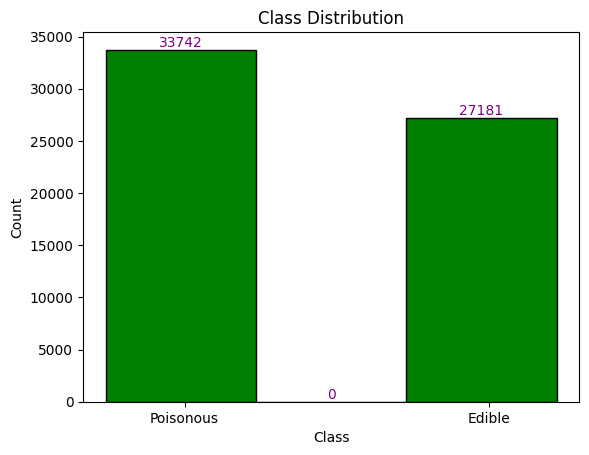

In [25]:
#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/
counts, bins, patches = plt.hist(df_clean['class'], bins=3, color='green', edgecolor='black')
plt.xticks([0.175, 0.85])
plt.bar_label(patches, color="purple")

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [26]:
df_clean['class'].value_counts(normalize=True).round(2)

,proportion
class,
Poisonous,0.55
Edible,0.45


The seaborn countplot determines the counts of each unique value for a particular feature. The important thing to note is that it is not the amount of mushrooms that matters for each unique value, but the distributions between each unique value, which is why crosstab is used below the visuals. If the difference is between the poisonous and edible classification is significant, then there might be significance for that unique value being a strong factor for determining mushroom edibility classification.

##Has-Ring Feature

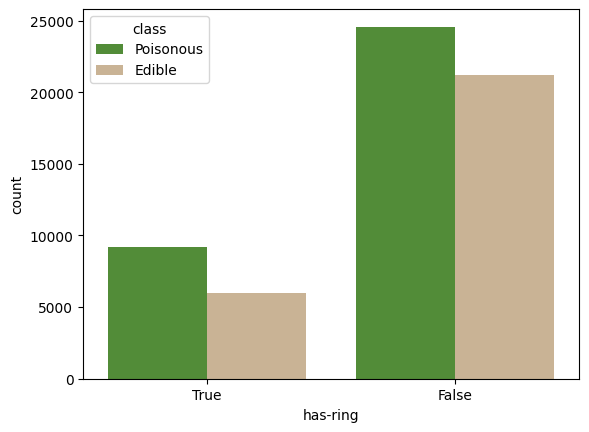

In [27]:
sns.countplot(x='has-ring', hue = 'class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [28]:
has_ring_dist = pd.crosstab(df_clean['has-ring'], df_clean['class'], normalize='index').round(2)
has_ring_dist

class,Edible,Poisonous
has-ring,,
False,0.46,0.54
True,0.40,0.60


This feature has-ring does not give a lot of information whether a mushroom is poisonous or not based on distributions. Habitat and seasons seem like the strongest predictors out of the four.

##Ring-Type Feature

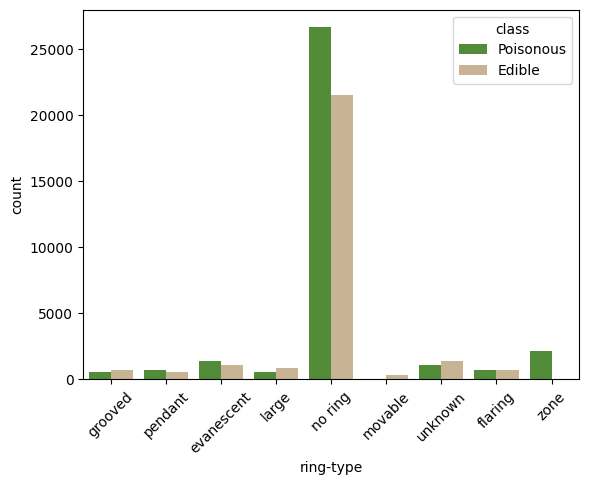

In [29]:
sns.countplot(x='ring-type', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.xticks(rotation=45)
plt.show()

In [30]:
ring_type_dist = pd.crosstab(df_clean['ring-type'], df_clean['class'], normalize='index').round(2)
ring_type_dist

class,Edible,Poisonous
ring-type,,
evanescent,0.43,0.57
flaring,0.50,0.50
grooved,0.57,0.43
large,0.61,0.39
movable,1.00,0.00
no ring,0.45,0.55
pendant,0.43,0.57
unknown,0.57,0.43
zone,0.00,1.00


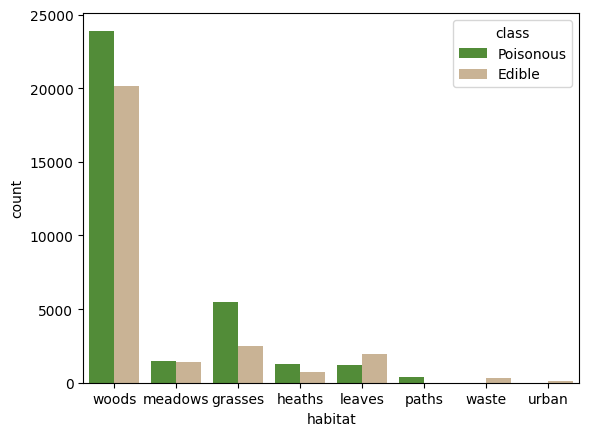

In [31]:
sns.countplot(x='habitat', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [32]:
#Numerical representation of the graph
habitat_dist = pd.crosstab(df_clean['habitat'], df_clean['class'], normalize='index').round(2)
habitat_dist

class,Edible,Poisonous
habitat,,
grasses,0.31,0.69
heaths,0.35,0.65
leaves,0.61,0.39
meadows,0.49,0.51
paths,0.00,1.00
urban,1.00,0.00
waste,1.00,0.00
woods,0.46,0.54


Mushrooms that live in paths, waste, and urban are determining factors that we can say it is one of the other immediately. Grasses and woods have significant differences so that could be a unique value for determining mushroom classification. Overall between habitat and ring-type, habitat seems like the stronger predictor for determining mushroom edibility

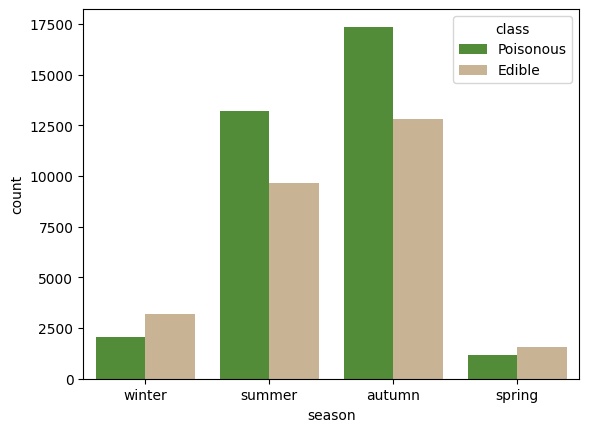

In [33]:
sns.countplot(x='season', hue='class', palette=["#4C9A2A", "#D2B48C"], data=df_clean)
plt.show()

In [34]:
season_dist = pd.crosstab(df_clean['season'], df_clean['class'], normalize='index').round(2)
season_dist

class,Edible,Poisonous
season,,
autumn,0.42,0.58
spring,0.58,0.42
summer,0.42,0.58
winter,0.61,0.39


The seasons predictor shows us that winter and spring mushrooms are more likely to be edible, while summer and autumn appear to have more poisonous mushrooms.

Train_test_split

In [35]:
misc_feats = df_clean[['ring-type', 'has-ring', 'habitat', 'season']]

In [36]:
X = misc_feats
y = df_clean["class"]

X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(X,y,test_size=0.2,random_state=42)
X_train_one_hot, X_test_one_hot, y_train_one_hot, y_test_one_hot = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X.shape

(60923, 4)

In [38]:
y.shape

(60923,)

Encoding Features for Model
Using OrdinalEncoder for Tree Models since Tree models make decisions on features not on distance values.
Using OneHotEncoder for Logistic Regression and SVM since those models use distances to determine classification.

###Ordinal Encoding for Tree Models:

In [39]:
ordinal_encoder = OrdinalEncoder()
X_train_ord_encoded = ordinal_encoder.fit_transform(X_train_ord)
X_test_ord_encoded = ordinal_encoder.transform(X_test_ord)

###OneHotEncoding for Logistic Regression and SVM:

When categorical attributes has hundreds or thousands of categories, one-hot encoding results in a very large matrix fulls of 0s except for a single 1 per row. A sparse matrix is needed because it will save memory and speed up compuatations - Geron book

In [40]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
X_train_one_hot_encoded = one_hot_encoder.fit_transform(X_train_one_hot)
X_test_one_hot_encoded = one_hot_encoder.transform(X_test_one_hot)

###Creating Model Pipelines

In [41]:
decision_tree_pipeline = Pipeline([
    ("encoder", ordinal_encoder),
    ("model", DecisionTreeClassifier(random_state=42))
])
random_forest_pipeline = Pipeline([
    ("encoder", ordinal_encoder),
    ("model", RandomForestClassifier(random_state=42))
])
log_reg_pipeline = Pipeline([
    ("encoder", one_hot_encoder),
    ("model", LogisticRegression(random_state=42))
])
svm_pipeline = Pipeline([
    ("encoder", one_hot_encoder),
    ("model", SVC(random_state=42, probability = True))
])

##Decision Tree

In [42]:
#Fit the tree pipeline and have it predict
decision_tree_pipeline.fit(X_train_ord, y_train_ord)
d_tree_pred = decision_tree_pipeline.predict(X_test_ord)

In [43]:
d_tree_cv_scores = cross_val_score(decision_tree_pipeline, X_train_ord, y_train_ord, cv=5, scoring='accuracy')
d_tree_cv_scores = d_tree_cv_scores = d_tree_cv_scores.mean().round(4)
d_tree_cv_scores

np.float64(0.6279)

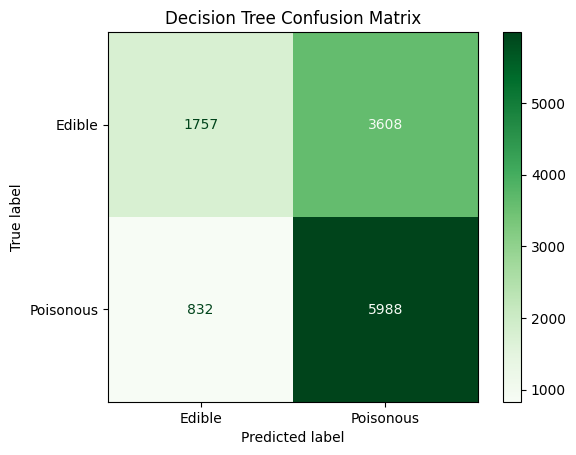

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test_ord, d_tree_pred, cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.show()

The confusion matrix displays information on model performance. The top left square shows that 1408 predicted edible mushrooms correctly and predicting 6176 poisonous mushrooms correctly. Based on our data set it seems that the decision tree has a difficult time classifying edible mushrooms when the model labels it poisonous which is better than it struggling to correctly classify poisonous mushrooms and the model predicting it as edible. **(false positive is worse case scenario)**.

Having a confusion matrix for our model evaluation helps determine what our models strengths and weakness arise. Since accuracy is not the tell all metric, precision, recall, f1-score, and roc-auc score are used to help give a more "accurate" (ironic) intepretation of the model performance.

In [45]:
precision_d_tree = precision_score(y_test_ord, d_tree_pred, pos_label="Poisonous")
precision_d_tree = round(precision_d_tree, 4)
precision_d_tree

0.624

The formula for precision, which measures the accuracy of positive predictions, is:

Precision = TP / (TP + FP)

In the context of the mushroom dataset, precision measures how often mushrooms predicted to be poisonous are actually poisonous. A high precision means there are few false positives (edible mushrooms incorrectly classified as poisonous). The precision is () which shows that the decision tree did a () job at classifying edible mushrooms



In [46]:
recall_d_tree = recall_score(y_test_ord, d_tree_pred, pos_label="Poisonous")
recall_d_tree = round(recall_d_tree, 4)
recall_d_tree

0.878

The formula for recall, which measures actual positive cases that are correctly identified:

Recall = TP / (TP + FN)

In the context of the mushroom dataset, recall measures how many of the actual poisonous mushrooms are correctly identified as poisonous. A high recall means there are few false negatives (poisonous mushrooms incorrectly classified as edible). The decision tree gave a high recall score of 0.90 so it accurate predicts an important safety hazard well which is confusing edible mushrooms with poisionous mushrooms.

In [47]:
f1_score_d_tree = f1_score(y_test_ord, d_tree_pred, pos_label="Poisonous")
f1_score_d_tree = round(f1_score_d_tree, 4)
f1_score_d_tree

0.7295

The f1-score measures both precision and recall and combines them using a harmonic mean, which is bias toward lower score values. In this case, the precision is lower than recall so our f-score reflects a score that is closer to precision than recall.

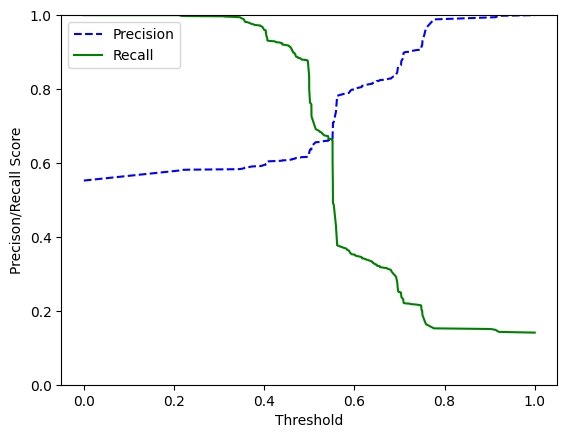

In [48]:
#Code inspiration from Aurelien Geron's "Hands-On Machine Learning with Scikit-Learn, Keras & Tensorflow"

y_dtree_scores = cross_val_predict(decision_tree_pipeline, X_train_ord, y_train_ord, cv=5, method='predict_proba')
precisions, recalls, thresholds = precision_recall_curve(y_train_ord, y_dtree_scores[:, 1], pos_label="Poisonous") #indexing the y_dtree_scores
#in such a manner because predicting poisonous mushroom is what's most important for the research.

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precison/Recall Score")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

This precision recall graph shows the tradeoff between these metrics with the trend being that as precision rises recall decreases and vice versa. However since it is very crucial to be able to predict poisionous mushrooms correctly, having a higher recall is a better model in our data set because it measures how accurately poisionous mushrooms are classified correctly. The decision tree has a good recall score of 0.90 which is highly valued for deciding what model to use for our data.

In [49]:
roc_auc_dtree = roc_auc_score(y_train_ord, y_dtree_scores[:, 1]).round(4)
roc_auc_dtree

np.float64(0.6964)

The roc_auc_score is low meaning the decision tree model does not overall predict mushroom classification too well. However based on our study of other metrics such as precision and recall, the recall having such a high value makes this model useful in this context.

##Random Forest

In [50]:
random_forest_pipeline.fit(X_train_ord, y_train_ord)
rf_pred = random_forest_pipeline.predict(X_test_ord)

In [51]:
rf_cv_scores = cross_val_score(random_forest_pipeline, X_train_ord, y_train_ord, cv=5, scoring='accuracy')
rf_cv_scores = rf_cv_scores.mean().round(4)
rf_cv_scores

np.float64(0.6278)

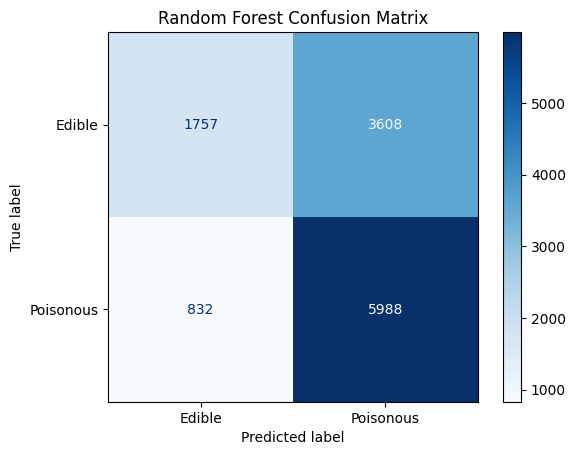

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test_ord, rf_pred, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [53]:
precision_rf = precision_score(y_test_ord, rf_pred, pos_label="Poisonous")
precision_rf = round(precision_rf, 4)
precision_rf

0.624

In [54]:
recall_rf = recall_score(y_test_ord, rf_pred, pos_label="Poisonous")
recall_rf = round(recall_rf, 4)
recall_rf

0.878

In [55]:
f1_score_rf = f1_score(y_test_ord, rf_pred, pos_label="Poisonous")
f1_score_rf = round(f1_score_rf, 4)
f1_score_rf

0.7295

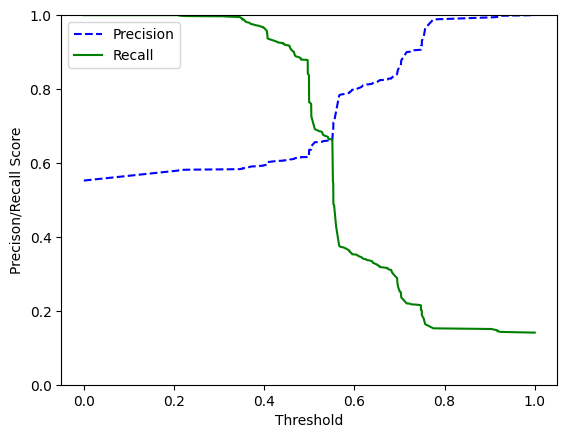

In [56]:
#Code inspiration from Aurelien Geron's "Hands-On Machine Learning with Scikit-Learn, Keras & Tensorflow"

y_rf_scores = cross_val_predict(random_forest_pipeline, X_train_ord, y_train_ord, cv=5, method='predict_proba')
precisions, recalls, thresholds = precision_recall_curve(y_train_ord, y_rf_scores[:, 1], pos_label="Poisonous") #indexing the y_rf_scores
#in such a manner because predicting poisonous mushroom is what's most important for the research.

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precison/Recall Score")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

In [57]:
roc_auc_rf = roc_auc_score(y_train_ord, y_rf_scores[:, 1]).round(4)
roc_auc_rf

np.float64(0.6962)

The Random Forest and Decision Tree Model have very similar metrics, with random forest having slightly better or on par metrics with Decision Trees. The decision tree model however is a simpler model so the decision tree model is prefered because it is computationally less expensive with similar metrics to Random forest.

##Logistic Regression

In [58]:
log_reg_pipeline.fit(X_train_one_hot, y_train_one_hot)
lr_pred = log_reg_pipeline.predict(X_test_one_hot)

In [59]:
lr_cv_scores = cross_val_score(log_reg_pipeline, X_train_one_hot, y_train_one_hot, cv=5, scoring='accuracy')
lr_cv_scores = lr_cv_scores.mean().round(4)
lr_cv_scores

np.float64(0.6165)

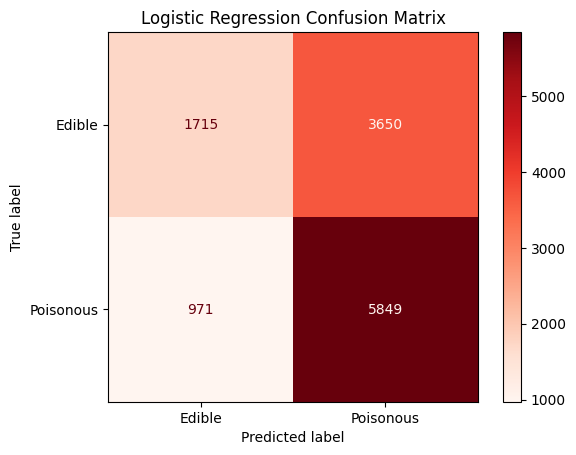

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test_one_hot, lr_pred, cmap='Reds')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [61]:
precision_lr = precision_score(y_test_one_hot, lr_pred, pos_label="Poisonous")
precision_lr = round(precision_lr, 4)
precision_lr

0.6157

In [62]:
recall_lr = recall_score(y_test_one_hot, lr_pred, pos_label="Poisonous")
recall_lr = round(recall_lr, 4)
recall_lr

0.8576

In [63]:
f1_score_lr = f1_score(y_test_one_hot, lr_pred, pos_label="Poisonous")
f1_score_lr = round(f1_score_lr, 4)
f1_score_lr

0.7168

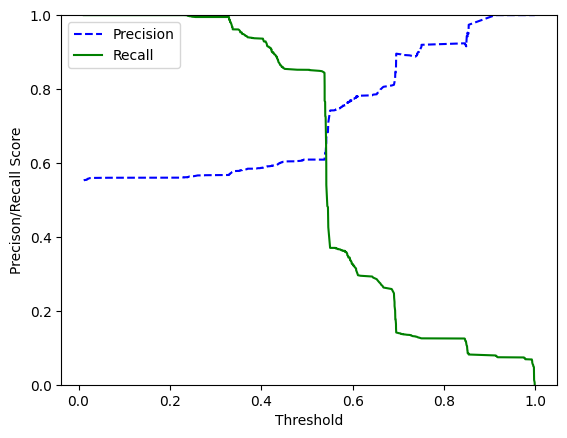

In [64]:
#Code inspiration from Aurelien Geron's "Hands-On Machine Learning with Scikit-Learn, Keras & Tensorflow"

y_lr_scores = cross_val_predict(log_reg_pipeline, X_train_one_hot, y_train_one_hot, cv=5, method='predict_proba')
precisions, recalls, thresholds = precision_recall_curve(y_train_one_hot, y_lr_scores[:, 1], pos_label="Poisonous") #indexing the y_lr_scores
#in such a manner because predicting poisonous mushroom is what's most important for the research.

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precison/Recall Score")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

In [65]:
roc_auc_log = roc_auc_score(y_train_one_hot, y_lr_scores[:, 1]).round(4)
roc_auc_log

np.float64(0.6644)

##SVM

In [66]:
svm_pipeline.fit(X_train_one_hot, y_train_one_hot)
svm_pred = svm_pipeline.predict(X_test_one_hot)

In [67]:
svm_cv_scores = cross_val_score(svm_pipeline, X_train_one_hot, y_train_one_hot, cv=5, scoring='accuracy')
svm_cv_scores = svm_cv_scores.mean().round(4)
svm_cv_scores

np.float64(0.6285)

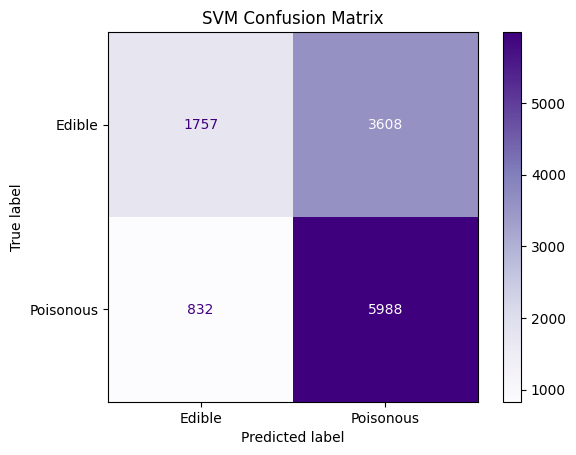

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test_one_hot, svm_pred, cmap='Purples')
plt.title('SVM Confusion Matrix')
plt.show()

In [69]:
precision_svm = precision_score(y_test_one_hot, svm_pred, pos_label="Poisonous")
precision_svm = round(precision_svm, 4)
precision_svm

0.624

In [70]:
recall_svm = recall_score(y_test_one_hot, svm_pred, pos_label="Poisonous")
recall_svm = round(recall_svm, 4)
recall_svm

0.878

In [71]:
f1_score_svm = f1_score(y_test_one_hot, svm_pred, pos_label="Poisonous")
f1_score_svm = round(f1_score_svm, 4)
f1_score_svm

0.7295

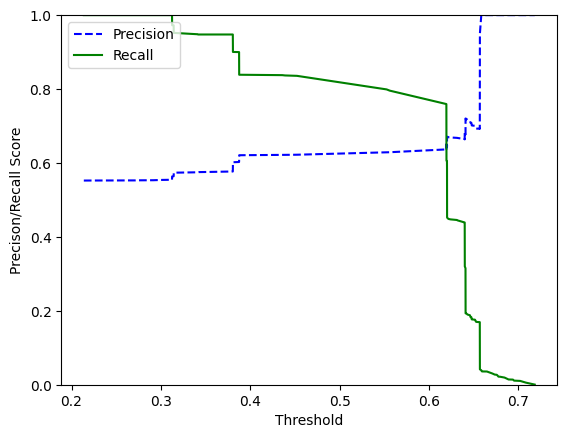

In [72]:
#Code inspiration from Aurelien Geron's "Hands-On Machine Learning with Scikit-Learn, Keras & Tensorflow"

y_svm_scores = cross_val_predict(svm_pipeline, X_train_one_hot, y_train_one_hot, cv=5, method='predict_proba')
precisions, recalls, thresholds = precision_recall_curve(y_train_one_hot, y_svm_scores[:, 1], pos_label="Poisonous") #indexing the y_svm_scores
#in such a manner because predicting poisonous mushroom is what's most important for the research.

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precison/Recall Score")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

In [73]:
roc_auc_svm = roc_auc_score(y_train_one_hot, y_svm_scores[:, 1]).round(4)
roc_auc_svm

np.float64(0.6456)

##Results Table

In [74]:
model_results = {
"Model": ["Decision Tree", "Random Forest", "Logistic Regression", "SVM"],
"Accuracy": [d_tree_cv_scores, rf_cv_scores, lr_cv_scores, svm_cv_scores],
"Precision": [precision_d_tree, precision_rf, precision_lr, precision_svm],
"Recall": [recall_d_tree, recall_rf, recall_lr, recall_svm],
"F1": [f1_score_d_tree, f1_score_rf, f1_score_lr, f1_score_svm],
"ROC-AUC": [roc_auc_dtree, roc_auc_rf, roc_auc_log, roc_auc_svm]
}

model_results = pd.DataFrame(model_results)
model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.6279,0.6240,0.8780,0.7295,0.6964
1,Random Forest,0.6278,0.6240,0.8780,0.7295,0.6962
2,Logistic Regression,0.6165,0.6157,0.8576,0.7168,0.6644
3,SVM,0.6285,0.6240,0.8780,0.7295,0.6456


##Conclusions:

Based on these four features of the mushroom data set